In [1]:
# You can copy this entire code block into a single cell in your Jupyter Notebook.
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# =================================================================================
#  FUNCTION 1: For creating a simple, single pulse sequence
# =================================================================================
def create_simple_sequence(pulse_sequence_steps, channel_mapping):
    """
    Processes a user-defined sequence and returns the low-level data and total period.
    This is ideal for creating a single, fixed sequence.

    Args:
        pulse_sequence_steps (list): A list of dictionaries defining the pulse sequence.
        channel_mapping (dict): A map of channel names to physical channel numbers.

    Returns:
        tuple: (low_level_sequence, total_period_us)
    """
    print("--- Creating simple sequence ---")
    total_period_us = sum(step['duration_us'] for step in pulse_sequence_steps)
    
    low_level_sequence = []
    for step in pulse_sequence_steps:
        duration_ns = int(step['duration_us'] * 1000)
        # Safely get channel list, defaulting to empty if not provided
        channel_names_on = step.get('channels_on', [])
        high_channels = [channel_mapping.get(name) for name in channel_names_on]
        
        if duration_ns > 0:
            low_level_sequence.append((duration_ns, high_channels, 0.0, 0.0))
            
    print(f"Total sequence duration: {total_period_us:.2f} µs")
    return low_level_sequence, total_period_us

# =================================================================================
#  FUNCTION 2: For creating a continuous sweep sequence
# =================================================================================
def create_sweep_sequence(sweep_params, subsequence_generator, channel_mapping):
    """
    Generates one single, continuous sequence for a sweep experiment.

    Args:
        sweep_params (dict): A dictionary with 'start', 'end', and 'steps' for the sweep.
        subsequence_generator (function): A function that takes a sweep value
                                          and returns the pulse steps for one sub-sequence.
        channel_mapping (dict): A map of channel names to physical channel numbers.

    Returns:
        tuple: (full_low_level_sequence, total_duration_us)
    """
    print(f"--- Creating sweep sequence with {sweep_params['steps']} steps ---")
    sweep_values = np.linspace(sweep_params['start'], sweep_params['end'], sweep_params['steps'])
    
    full_sequence_data = []
    
    for value in sweep_values:
        # 1. Generate the sub-sequence for the current sweep value
        sub_sequence_steps = subsequence_generator(value)
        
        # 2. Convert the sub-sequence to low-level format and append it
        for step in sub_sequence_steps:
            duration_ns = int(step['duration_us'] * 1000)
            channel_names_on = step.get('channels_on', [])
            high_channels = [channel_mapping.get(name) for name in channel_names_on]
            
            if duration_ns > 0:
                full_sequence_data.append((duration_ns, high_channels, 0.0, 0.0))

    total_duration_ns = sum(p[0] for p in full_sequence_data)
    total_duration_us = total_duration_ns / 1000.0
    
    print(f"Total continuous sequence duration: {total_duration_us:.2f} µs")
    return full_sequence_data, total_duration_us


# =================================================================================
#  PLOTTING FUNCTION (Adapted to plot a portion of a long sequence)
# =================================================================================
def plot_sequence(low_level_sequence, channel_mapping, plot_duration_us=None, title='Pulse Sequence'):
    """
    Generates a plot for a low-level pulse sequence. Can plot a partial duration.
    """
    plot_data = low_level_sequence
    
    # If a plot duration is specified, truncate the data for plotting
    if plot_duration_us is not None:
        plot_duration_ns = plot_duration_us * 1000
        plot_data = []
        current_time_ns = 0
        for pulse in low_level_sequence:
            plot_data.append(pulse)
            current_time_ns += pulse[0]
            if current_time_ns >= plot_duration_ns:
                break
    
    print(f"--- Generating Plot: {title} ---")
    fig, ax = plt.subplots(figsize=(15, 6))
    channel_names = {v: k for k, v in channel_mapping.items()}
    # Plot all channels defined in the map
    active_channels = sorted(list(channel_mapping.values()))

    for chan_num in active_channels:
        x_coords, y_coords = [0], [0]
        current_time_ns = 0
        for duration_ns, high_channels, _, _ in plot_data:
            level = 1 if chan_num in high_channels else 0
            if y_coords[-1] != level:
                x_coords.append(current_time_ns)
                y_coords.append(level)
            current_time_ns += duration_ns
            x_coords.append(current_time_ns)
            y_coords.append(level)
        
        time_us = np.array(x_coords) / 1000.0
        waveform = np.array(y_coords) * 0.8 + (chan_num - 1)
        ax.plot(time_us, waveform, label=channel_names.get(chan_num, f'CH {chan_num}'))

    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Time (µs)', fontsize=12)
    ax.set_ylabel('Digital Channel', fontsize=12)
    ax.set_yticks([ch - 1 for ch in active_channels])
    ax.set_yticklabels([channel_names.get(ch, f'CH {ch}') for ch in active_channels])
    ax.set_ylim(-0.5, 8)
    ax.grid(axis='y', linestyle=':')
    ax.legend()
    plt.show()

print("Helper functions are defined and ready to use.")

Helper functions are defined and ready to use.


In [5]:
# --- Define hardware channels ---
# Renamed channels for clarity in this new experiment.
# Pulse_1 will be the 100 µs pulse, Pulse_2 will be the 50 µs pulse.
channel_map = {
    'Pulse_1': 1,
    'Pulse_2': 1,
    'Trigger': 5,      # Available but not used in this sequence
    'Microwave': 7,    # Available but not used in this sequence
}

--- Creating sweep sequence with 150 steps ---
Total continuous sequence duration: 60082.43 µs
--- Generating Plot: Time Delay Sweep (First 3 Steps) ---


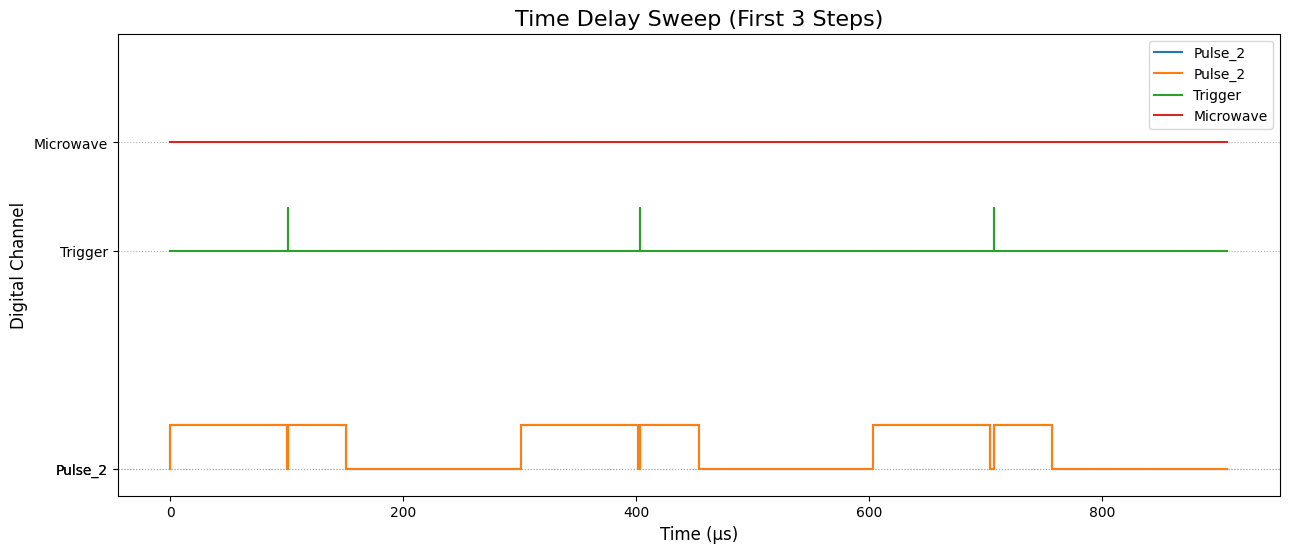

In [ ]:
# --- 1. Define Sweep and Pulse Parameters ---
# Define the sweep for the waiting time between the two main pulses.
wait_time_sweep = {
    'start': 0,    # Start with a 1 µs wait
    'end': 200,    # End with a 200 µs wait
    'steps': 200,   # Perform 50 steps as requested
}

# Define the fixed durations for the rest of the sequence
PULSE_1_DURATION_US = 130
PULSE_2_DURATION_US = 50
# After the second pulse, we add a fixed wait time for measurement/reset
# before the next step in the continuous sequence begins.
POST_PULSE_WAIT_US = 150
TRIGGER_DURATION_US: float = 0.05 # Duration for the trigger pulse, if used

# --- 2. Define the Sub-Sequence Generator for this Experiment ---
# This function defines the structure of ONE step in the sweep.
# Its input is the wait time for the current step.
def time_delay_subsequence_generator(swept_wait_time_us):
    """
    Generates the sequence: [100µs Pulse] -> [Swept Wait] -> [50µs Pulse] -> [Fixed Wait]
    """
    sub_sequence = [
        # Part 1: The starting 100 µs pulse
        {'duration_us': PULSE_1_DURATION_US, 'channels_on': ['Pulse_1']},
        
        # Part 2: The variable waiting time, passed in as an argument
        {'duration_us': swept_wait_time_us, 'channels_on': []},
        
        {'duration_us': TRIGGER_DURATION_US, 'channels_on': ['Trigger']},
        # Part 3: The second 50 µs pulse
        {'duration_us': PULSE_2_DURATION_US, 'channels_on': ['Pulse_2']},
        
        # Part 4: A fixed wait/readout time before the next sequence starts
        {'duration_us': POST_PULSE_WAIT_US, 'channels_on': []},
        
         

    ]
    return sub_sequence

# --- 3. Create the full, continuous sweep sequence ---
full_sweep_sequence, total_duration = create_sweep_sequence(
    wait_time_sweep,
    time_delay_subsequence_generator,
    channel_map
)

# --- 4. Plot the first few steps for verification ---
# Calculate the duration of the first 3 steps to set a sensible plot window
# Note: we use the START of the sweep for this calculation.
one_step_duration = PULSE_1_DURATION_US + wait_time_sweep['start'] + PULSE_2_DURATION_US + POST_PULSE_WAIT_US
plot_window = one_step_duration * 3 # Plot the first 3 cycles

plot_sequence(
    full_sweep_sequence,
    channel_map,
    plot_duration_us=plot_window,
    title="Time Delay Sweep (First 3 Steps)"
)

In [21]:
print("Uploading sequence with trigger and repump to the Pulse Streamer...")

pulsestreamer.upload_sequence(full_sweep_sequence)

print("Starting the pulse sequence...")

pulsestreamer.start_streaming(n_runs=-1)


Uploading sequence with trigger and repump to the Pulse Streamer...
Starting the pulse sequence...
